In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

from utils import *
from data import *
from data_utils import *
from power_method_svd import power_svd


device = 'cuda:0'

In [2]:
dataset = 'syn'
print(dataset)
if dataset == 'syn':
    r = 1
    d1 = 100
    d2 = 1000
    _, _, M = load_data_syn(r, d1, d2, device)
else:
    M = load_data_all(dataset)
    M = M.float().to(device)
    d1, d2 = M.shape
    r=5

# generate data
# d1 >> d2
#p = 2.0 / d2
p = 0.2
#p = 0.5
 
#_, _, M = load_data_syn(r, d1, d2, device)
#M = torch.from_numpy(get_random_matrix(d1, d2, r))
#M = M.to(device).float()

#M = get_random_matrix(d1, d2, r) / np.sqrt(d1)
#M = get_random_matrix(d1, d2, r)
#M = torch.normal(2, 1, size = (d1, d2)).to(device)
observed_M, masks = get_masks(M, p)

#M = torch.from_numpy(M).to(device).float()
#observed_M = torch.from_numpy(observed_M).to(device).float()
#masks = torch.from_numpy(masks).to(device).float()

non_zero_rows = torch.any(observed_M != 0, dim=1)

observed_M = observed_M[non_zero_rows]
masks = masks[non_zero_rows]
M = M[non_zero_rows]
print(M.shape)

syn
Non-zero elements do not align correctly with the mask.
torch.Size([100, 1000])


In [3]:
#eps = 0.01

cov_observe_M =  observed_M.T @ observed_M
cov_observe_count = (observed_M == 0).float().t() @ (observed_M == 0).float()
diag_cov = torch.diag( torch.diag(cov_observe_M) )

torch.count_nonzero(cov_observe_M).item()

984420

In [4]:
cov_observe_count = (1 * (observed_M != 0)).float().T @ (1 * (observed_M != 0).float())
cov_observe_count = cov_observe_count + (cov_observe_count == 0) * 1
T = cov_observe_M / (cov_observe_count/d1)
MTM = M.T @ M
T_masks = 1 * (T!=0)
print(T_masks.min())

tensor(0, device='cuda:0')


In [5]:
"""
T_masks = torch.nonzero(T)

mask_err = T[T_masks] - MTM[T_masks]

print(torch.norm(mask_err) / torch.norm(MTM, 'fro'))
"""

"\nT_masks = torch.nonzero(T)\n\nmask_err = T[T_masks] - MTM[T_masks]\n\nprint(torch.norm(mask_err) / torch.norm(MTM, 'fro'))\n"

In [6]:
"""
T_p = (1.0 / p) * diag_cov + (1.0 / (p**2)) * (cov_observe_M - diag_cov)

mask_err_Tp = T_p[T_masks] - MTM[T_masks]

print(torch.norm(mask_err_Tp) / torch.norm(MTM, 'fro'))
"""

"\nT_p = (1.0 / p) * diag_cov + (1.0 / (p**2)) * (cov_observe_M - diag_cov)\n\nmask_err_Tp = T_p[T_masks] - MTM[T_masks]\n\nprint(torch.norm(mask_err_Tp) / torch.norm(MTM, 'fro'))\n"

tensor(984420, device='cuda:0')


relative err: 0.2408043: 100%|██████████| 30/30 [00:00<00:00, 178.49it/s]


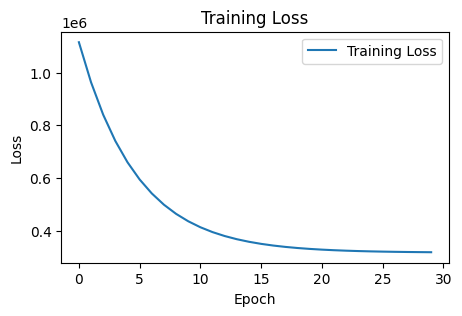

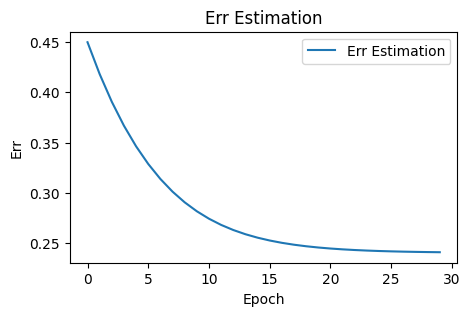

In [7]:
# impute missing values from rank-r SVD corresponding to masks
use_power_method = True
train_losses = []
err_estimates = []

epochs = 30
tol = 1e-5
lr = 0.1
X = T
#T_masks = 1 * (T != 0)
print(T_masks.sum())
loop = tqdm(range(epochs))
for i in loop:
    if not use_power_method:
        U, D, Vt = torch.linalg.svd(X)
        D[r:] = 0
        X_update = U @ torch.diag(D) @ Vt
    else:
        U, D, Vt = power_svd(X, k=r)
        X_update = U @ torch.diag(D) @ Vt

    #X = X * T_masks + X_update * (1 - T_masks)
    X = X * (1-lr) + X_update * lr
    err = MTM - X
    loss = (err**2).mean()
    train_losses.append(loss.item())
    relative_err = torch.norm(err, 'fro') / torch.norm(MTM, 'fro')
    #if i > 10:
    #    if relative_err - last_err < tol:
    #        break
    last_err = relative_err
    loop.set_description(f"relative err: {relative_err:.7f}")
    err_estimates.append(relative_err.item())
    #print(relative_err)

plt.figure(figsize=(5, 3))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

plt.figure(figsize=(5, 3))
plt.plot(err_estimates, label='Err Estimation')
plt.xlabel('Epoch')
plt.ylabel('Err')
plt.title('Err Estimation')
plt.legend()

$U\times V = M$ 

In order to solve $AX=B$, we have 

$
X=U^T \in r\times d_1, \\
A=V^T \in d_2\times r, \\
B=M^T \in d_2\times d_2
$

Then $V^TU^T=M^T$


In [10]:
error_list = []
missing_num = 0
total_num = 0
skip = 0
result_list_missing = []
result_list_total = []
use_reg = True
U = []

#estimation_goal = torch.rand(X.shape).to(device)
estimation_goal = X

#_, S, V = top_r_svd(estimation_goal, r)
_, _, V = power_svd(estimation_goal, k=r)
for i in tqdm(range(M.shape[0])):
    """
    M_row: 1*d2
    V: r*d2
    user_vector: 1*r
    """

    # make sure there is non-zero value in original matrix
    M_row = M[i]
    non_zero_indices = M_row.nonzero(as_tuple=True)[0]

    #non_zero_indices = torch.tensor(range(M_row.shape[0]))

    # select non-zero & masked elements as training data, non-zero & non-masked elements as testing data
    """
    observed_idx = []
    missing_idx = []
    for non_zero_idx in non_zero_indices:
        if masks[i][non_zero_idx]:
            observed_idx.append(non_zero_idx.item())
        else:
            missing_idx.append(non_zero_idx.item())
    """

    # Get the mask values for the non-zero indices
    mask_values = masks[i][non_zero_indices]

    # Use boolean indexing to separate observed and missing indices
    observed_idx = non_zero_indices[mask_values]
    missing_idx = non_zero_indices[~mask_values]

    M_row = M_row.unsqueeze(0)
    n = non_zero_indices.shape[0]

    #if len(observed_idx)==0 or len(missing_idx) == 0:
    #    skip +=1
    #    continue
    
    missing_num += len(missing_idx)
    total_num += len(missing_idx) + len(observed_idx)

    observed_idx = torch.tensor(observed_idx)
    missing_idx = torch.tensor(missing_idx)

    # formula AX=B
    observed_A = V[:, observed_idx].t()
    observed_B = M_row[:, observed_idx].t()
    missing_A = V[:, missing_idx].t()
    missing_B = M_row[:, missing_idx].t()

    if use_reg:
        # Ridge regression
        lambda_reg = 0.001
        I = torch.eye(observed_A.shape[1], device=device) * lambda_reg
        u = torch.linalg.lstsq(observed_A.t() @ observed_A + I, observed_A.t() @ observed_B).solution
    else:
        # Linear regression
        u = torch.linalg.lstsq(observed_A, observed_B).solution   
    U.append(u.t())

    check_vec = u
    if torch.any(torch.isnan(check_vec)):
        print("NAN!")
        print(check_vec)
        break

    # stat |AX-B| by individual elements
    if not (len(observed_idx)==0 or len(missing_idx)) == 0:
        error_list.append(torch.sum((missing_A @ u - missing_B)**2).item())

# stat |AX-B| by the estimationed matrix
"""
U = torch.concat(U, dim=0)
M_ret = U @ V
err = torch.norm((M-M_ret)*masks, p=2) / np.sqrt(missing_num)
print(err)
"""
# stat |AX-B| by individual elements
ret = np.sqrt(np.sum(error_list)/missing_num)
result_list_missing.append(np.sqrt(np.sum(error_list)/missing_num))
#result_list_total.append(np.sqrt(np.sum(error_list))/total_num)
print(np.mean(result_list_missing))
print(np.std(result_list_missing))
#print(np.mean(result_list_total))
#print(np.std(result_list_total))




  0%|          | 0/100 [00:00<?, ?it/s]

/tmp/ipykernel_65624/740747691.py:56: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  observed_idx = torch.tensor(observed_idx)
/tmp/ipykernel_65624/740747691.py:57: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  missing_idx = torch.tensor(missing_idx)
100%|██████████| 100/100 [00:00<00:00, 818.28it/s]

0.8716063037809282
0.0


In [9]:
"""
import torch.nn.utils.rnn as rnn_utils
error_list = []
missing_num = 0
total_num = 0
skip = 0
result_list_missing = []
result_list_total = []
use_reg = False
U = []

#estimation_goal = torch.rand(X.shape).to(device)
estimation_goal = X

observed_A_list = []
observed_B_list = []

#_, S, V = top_r_svd(estimation_goal, r)
_, _, V = power_svd(estimation_goal, k=r)
for i in tqdm(range(M.shape[0])):
    
    # M_row: 1*d2
    # V: r*d2
    # user_vector: 1*r
    

    # make sure there is non-zero value in original matrix
    M_row = M[i]
    non_zero_indices = M_row.nonzero(as_tuple=True)[0]

    #non_zero_indices = torch.tensor(range(M_row.shape[0]))

    # select non-zero & masked elements as training data, non-zero & non-masked elements as testing data
    observed_idx = []
    missing_idx = []
    for non_zero_idx in non_zero_indices:
        if masks[i][non_zero_idx]:
            observed_idx.append(non_zero_idx.item())
        else:
            missing_idx.append(non_zero_idx.item())

    M_row = M_row.unsqueeze(0)
    n = non_zero_indices.shape[0]

    #if len(observed_idx)==0 or len(missing_idx) == 0:
    #    skip +=1
    #    continue
    missing_num += len(missing_idx)
    total_num += len(missing_idx) + len(observed_idx)

    observed_idx = torch.tensor(observed_idx)
    missing_idx = torch.tensor(missing_idx)

    # formula AX=B
    observed_A = V[:, observed_idx].t()
    observed_B = M_row[:, observed_idx].t()
    missing_A = V[:, missing_idx].t()
    missing_B = M_row[:, missing_idx].t()

    observed_A_list.append(observed_A)
    observed_B_list.append(observed_B)

padded_A = rnn_utils.pad_sequence(observed_A_list, batch_first=True, padding_value=0)
padded_B = rnn_utils.pad_sequence(observed_B_list, batch_first=True, padding_value=0)

U_t = torch.linalg.lstsq(padded_A, padded_B).solution
U = U_t.squeeze(-1)
M_ret = U @ V
err = torch.norm(M-M_ret, p=2) / missing_num
print(err)
"""

'\nimport torch.nn.utils.rnn as rnn_utils\nerror_list = []\nmissing_num = 0\ntotal_num = 0\nskip = 0\nresult_list_missing = []\nresult_list_total = []\nuse_reg = False\nU = []\n\n#estimation_goal = torch.rand(X.shape).to(device)\nestimation_goal = X\n\nobserved_A_list = []\nobserved_B_list = []\n\n#_, S, V = top_r_svd(estimation_goal, r)\n_, _, V = power_svd(estimation_goal, k=r)\nfor i in tqdm(range(M.shape[0])):\n    \n    # M_row: 1*d2\n    # V: r*d2\n    # user_vector: 1*r\n    \n\n    # make sure there is non-zero value in original matrix\n    M_row = M[i]\n    non_zero_indices = M_row.nonzero(as_tuple=True)[0]\n\n    #non_zero_indices = torch.tensor(range(M_row.shape[0]))\n\n    # select non-zero & masked elements as training data, non-zero & non-masked elements as testing data\n    observed_idx = []\n    missing_idx = []\n    for non_zero_idx in non_zero_indices:\n        if masks[i][non_zero_idx]:\n            observed_idx.append(non_zero_idx.item())\n        else:\n           